# Competencia de Decadas - Parte 1

Este notebook reconstruye la solucion de la competencia siguiendo las pautas del enunciado de la **Parte 1**: unicamente se usan modelos clasicos de `scikit-learn`, el flujo es completamente reproducible y el trabajo queda autocontenido dentro del `.ipynb`.

La estructura sigue el estilo de las practicas del curso: exploracion, calidad de datos, preparacion del texto, representacion, construccion de `Pipeline`, comparacion de modelos, busqueda rapida de hiperparametros, evaluacion del mejor modelo y exportacion final.

In [7]:
from pathlib import Path
import json
import re
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from joblib import parallel_backend
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid')

## 1. Configuracion y funciones auxiliares

A diferencia de la version anterior, el notebook ya no depende de `train_and_submit.py`. Todas las funciones relevantes quedan definidas aqui: validacion de esquema, limpieza conservadora, benchmark de modelos, busqueda rapida y exportacion.

In [8]:
RANDOM_STATE = 42
VALIDATION_SIZE = 0.15
TRAIN_COLUMNS = {'text', 'decade'}
EVAL_COLUMNS = {'id', 'text'}


def find_project_dir():
    current = Path.cwd()
    if (current / 'train.csv').exists() and (current / 'eval.csv').exists():
        return current
    if (current / 'Proyecto' / 'train.csv').exists() and (current / 'Proyecto' / 'eval.csv').exists():
        return current / 'Proyecto'
    raise FileNotFoundError('No se encontro la carpeta Proyecto con train.csv y eval.csv.')


PROJECT_DIR = find_project_dir()
TRAIN_PATH = PROJECT_DIR / 'train.csv'
EVAL_PATH = PROJECT_DIR / 'eval.csv'
SUBMISSION_PATH = PROJECT_DIR / 'submission.csv'
MODEL_PATH = PROJECT_DIR / 'modelo_final.joblib'
METRICS_PATH = PROJECT_DIR / 'metricas_resumen.json'


def normalize_text(text):
    normalized = str(text)
    normalized = normalized.replace(chr(13) + chr(10), '\n').replace(chr(13), '\n')
    normalized = re.sub(r'\s+', ' ', normalized)
    return normalized.strip()


def validate_train_schema(train_df):
    missing = TRAIN_COLUMNS.difference(train_df.columns)
    if missing:
        raise ValueError(f'El train no contiene las columnas requeridas: {sorted(missing)}')


def validate_eval_schema(eval_df):
    missing = EVAL_COLUMNS.difference(eval_df.columns)
    if missing:
        raise ValueError(f'El eval no contiene las columnas requeridas: {sorted(missing)}')
    if eval_df['id'].duplicated().any():
        raise ValueError('El eval contiene ids duplicados.')


def schema_report(train_df, eval_df):
    validate_train_schema(train_df)
    validate_eval_schema(eval_df)
    return {
        'train_shape': tuple(train_df.shape),
        'eval_shape': tuple(eval_df.shape),
        'train_nulls': train_df[['text', 'decade']].isna().sum().to_dict(),
        'eval_nulls': eval_df[['id', 'text']].isna().sum().to_dict(),
        'num_classes': int(train_df['decade'].nunique()),
        'class_min': int(train_df['decade'].min()),
        'class_max': int(train_df['decade'].max()),
        'eval_id_duplicates': int(eval_df['id'].duplicated().sum()),
    }


def text_length_report(df, text_column='text'):
    lengths = pd.DataFrame({
        'n_chars': df[text_column].astype(str).map(len),
        'n_words': df[text_column].astype(str).str.split().str.len(),
    })
    return lengths.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T


def duplicate_conflict_report(train_df):
    report_df = train_df.copy()
    report_df['text'] = report_df['text'].map(normalize_text)
    duplicate_rows = int(report_df.duplicated(subset=['text']).sum())
    label_counts = report_df.groupby('text')['decade'].nunique()
    conflicting_texts = label_counts[label_counts > 1].index
    preview = (
        report_df.groupby('text')
        .agg(
            n=('text', 'size'),
            labels=('decade', lambda values: sorted(set(map(int, values)))),
        )
        .sort_values('n', ascending=False)
        .head(10)
        .reset_index()
    )
    return {
        'duplicated_text_rows': duplicate_rows,
        'unique_texts': int(report_df['text'].nunique()),
        'conflicting_texts': int(len(conflicting_texts)),
        'conflicting_rows': int(report_df['text'].isin(conflicting_texts).sum()),
        'preview': preview,
    }


def clean_training_data(train_df):
    cleaned = train_df.copy()
    cleaned['text'] = cleaned['text'].map(normalize_text)
    cleaned['decade'] = cleaned['decade'].astype(int)
    before_rows = len(cleaned)

    conflict_sizes = cleaned.groupby('text')['decade'].nunique()
    conflicting_texts = conflict_sizes[conflict_sizes > 1].index
    conflicting_rows = int(cleaned['text'].isin(conflicting_texts).sum())
    cleaned = cleaned.loc[~cleaned['text'].isin(conflicting_texts)].copy()

    duplicate_rows = int(cleaned.duplicated(subset=['text']).sum())
    cleaned = cleaned.drop_duplicates(subset=['text']).reset_index(drop=True)

    report = {
        'rows_before_cleaning': before_rows,
        'conflicting_texts_removed': int(len(conflicting_texts)),
        'conflicting_rows_removed': conflicting_rows,
        'duplicate_rows_removed': duplicate_rows,
        'rows_after_cleaning': int(len(cleaned)),
        'classes_after_cleaning': int(cleaned['decade'].nunique()),
    }
    return cleaned, report


def clean_evaluation_data(eval_df):
    cleaned = eval_df.copy()
    cleaned['text'] = cleaned['text'].map(normalize_text)
    return cleaned


def build_fixed_models():
    return {
        'char_tfidf_svc_final': Pipeline([
            ('vectorizer', TfidfVectorizer(
                analyzer='char',
                ngram_range=(3, 5),
                min_df=1,
                max_features=350000,
                sublinear_tf=True,
                strip_accents=None,
                lowercase=False,
            )),
            ('model', LinearSVC(
                C=1.0,
                random_state=RANDOM_STATE,
            )),
        ]),
    }


SEARCH_SPACES = {}


def evaluate_estimator(estimator, x_train, y_train, x_valid, y_valid):
    y_train_pred = estimator.predict(x_train)
    y_valid_pred = estimator.predict(x_valid)
    return {
        'train_accuracy': float(accuracy_score(y_train, y_train_pred)),
        'valid_accuracy': float(accuracy_score(y_valid, y_valid_pred)),
        'classification_report': classification_report(y_valid, y_valid_pred, zero_division=0),
        'classification_report_dict': classification_report(y_valid, y_valid_pred, output_dict=True, zero_division=0),
        'confusion_matrix': confusion_matrix(y_valid, y_valid_pred, labels=sorted(y_valid.unique())),
        'valid_predictions': y_valid_pred,
    }


def benchmark_models(models, x_train, y_train, x_valid, y_valid):
    rows = []
    fitted = {}
    evaluations = {}
    for model_name, model in models.items():
        start = time.perf_counter()
        model.fit(x_train, y_train)
        elapsed = time.perf_counter() - start
        fitted[model_name] = model
        evaluation = evaluate_estimator(model, x_train, y_train, x_valid, y_valid)
        evaluations[model_name] = evaluation
        rows.append({
            'model_name': model_name,
            'train_accuracy': evaluation['train_accuracy'],
            'valid_accuracy': evaluation['valid_accuracy'],
            'fit_seconds': elapsed,
            'searchable': model_name in SEARCH_SPACES,
        })
    summary = pd.DataFrame(rows).sort_values(['valid_accuracy', 'train_accuracy'], ascending=False).reset_index(drop=True)
    return summary, fitted, evaluations


def run_random_search(model_name, estimator, search_space, x_train, y_train, x_valid, y_valid):
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    total_combinations = len(ParameterGrid(search_space))
    n_iter = min(6, total_combinations)
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=search_space,
        n_iter=n_iter,
        scoring='accuracy',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
        return_train_score=True,
        verbose=1,
    )
    start = time.perf_counter()
    with parallel_backend('threading'):
        search.fit(x_train, y_train)
    elapsed = time.perf_counter() - start
    evaluation = evaluate_estimator(search.best_estimator_, x_train, y_train, x_valid, y_valid)
    return {
        'model_name': model_name,
        'fit_seconds': elapsed,
        'best_cv_accuracy': float(search.best_score_),
        'train_accuracy': evaluation['train_accuracy'],
        'valid_accuracy': evaluation['valid_accuracy'],
        'best_params': search.best_params_,
        'search': search,
        'evaluation': evaluation,
    }


def extract_top_features(estimator, top_n=10):
    vectorizer = estimator.named_steps['vectorizer']
    model = estimator.named_steps['model']
    if not hasattr(model, 'coef_'):
        raise ValueError('El modelo no expone coeficientes para interpretar caracteristicas.')
    feature_names = np.asarray(vectorizer.get_feature_names_out())
    rows = []
    for class_index, class_label in enumerate(model.classes_):
        coefficients = model.coef_[class_index]
        top_indices = np.argsort(coefficients)[-top_n:][::-1]
        for rank, feature_index in enumerate(top_indices, start=1):
            rows.append({
                'decade': int(class_label),
                'rank': rank,
                'feature': str(feature_names[feature_index]),
                'coefficient': float(coefficients[feature_index]),
            })
    return pd.DataFrame(rows)


def create_submission(eval_df, predictions):
    submission = pd.DataFrame({'id': eval_df['id'], 'answer': predictions.astype(int)})
    if len(submission) != len(eval_df):
        raise ValueError('El submission no tiene la misma cantidad de filas que eval.csv.')
    return submission


def make_json_safe(value):
    if isinstance(value, dict):
        return {str(key): make_json_safe(inner_value) for key, inner_value in value.items()}
    if isinstance(value, list):
        return [make_json_safe(item) for item in value]
    if isinstance(value, tuple):
        return [make_json_safe(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, pd.DataFrame):
        return make_json_safe(value.to_dict(orient='records'))
    if isinstance(value, pd.Series):
        return make_json_safe(value.to_dict())
    return value


## 2. Carga y validacion de los datos

Se cargan los archivos oficiales de la competencia. Aqui verificamos esquema, ausencia de nulos y rango de clases antes de entrenar cualquier modelo.

In [9]:
train_df = pd.read_csv(TRAIN_PATH)
eval_df = pd.read_csv(EVAL_PATH)
schema_info = schema_report(train_df, eval_df)

display(pd.DataFrame([schema_info]))
display(train_df.head(3))
display(eval_df.head(3))

,train_shape,eval_shape,train_nulls,eval_nulls,num_classes,class_min,class_max,eval_id_duplicates
0,"(31403, 2)","(3490, 2)","{'text': 0, 'decade': 0}","{'id': 0, 'text': 0}",39,150,188,0


,text,decade
0,"\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \nnes pa...",164
1,"gone. Sus amigos , sus clientes, todo \ncuanto le rodea le prueban que es hom- \nbre de mucha importancia. Si ve que al- \ngunos hombre»...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan feratormentados, e \nante quien,e quie preguntasles deuan hazer mientras los tormentarf, ...",157


,id,text
0,0,"P. Si en efta convocación trato folamente de comunicarles los artículos arregla- \ndos, y firmados, o de proponerles , qué ..."
1,1,"«Muy santo Padre : Ayer escribiá don Juan Man- \ny rique que dijese á vuestra Santidad, ó le escribie- \n»se, en cuán bucnos términos qu..."
2,2,"Recibo, otorgado por Diego Gracián a favor de Jerónimo Zurita, de un libro de Casiodoro, titulado \nDe Amicitia et Dilectione seu de Car..."


## 3. Exploracion del dataset

Como en las practicas, primero revisamos la distribucion de la variable objetivo y el tamano de los textos. Esto ayuda a justificar la representacion del texto y el tipo de modelo lineal que vamos a usar.

,count
decade,
150,786
151,812
152,785
153,775
154,830
155,836
156,792
157,827
158,778


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
n_chars,31403.0,520.56829,530.947792,120.0,139.0,182.0,315.0,643.0,1198.0,1627.0,2534.96,7418.0
n_words,31403.0,82.28319,82.374190,3.0,22.0,30.0,50.0,102.0,189.0,255.0,394.00,1146.0


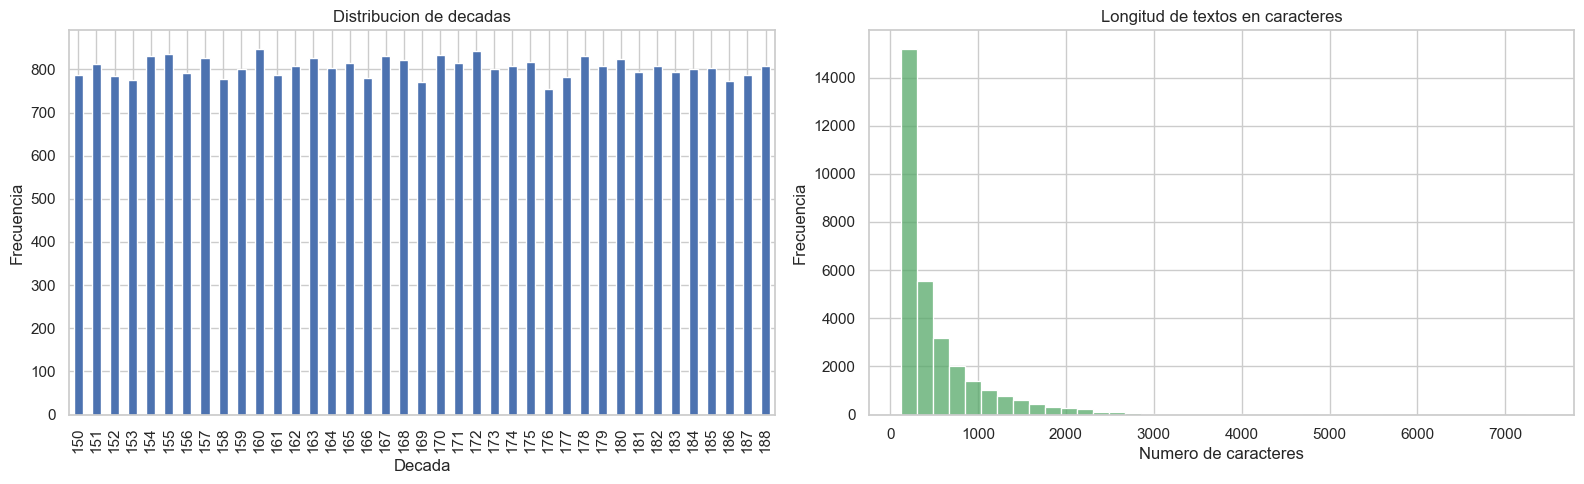

In [10]:
class_counts = train_df['decade'].value_counts().sort_index()
length_summary = text_length_report(train_df)

display(class_counts.to_frame(name='count').head(10))
display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
class_counts.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribucion de decadas')
axes[0].set_xlabel('Decada')
axes[0].set_ylabel('Frecuencia')

sns.histplot(train_df['text'].astype(str).map(len), bins=40, ax=axes[1], color='#55A868')
axes[1].set_title('Longitud de textos en caracteres')
axes[1].set_xlabel('Numero de caracteres')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 4. Calidad de datos y limpieza conservadora

La practica de procesamiento de textos muestra tokenizacion, stemming y lematizacion; sin embargo, aqui **no** conviene usar esa limpieza agresiva como paso final del modelo. Este dataset es historico, tiene OCR ruidoso y ortografia antigua, y esas variaciones son parte de la senal que ayuda a distinguir decadas.

Por eso la limpieza final sera minima:

- convertir todo a `str`;
- normalizar espacios y saltos de linea;
- eliminar textos con etiquetas conflictivas;
- eliminar duplicados exactos restantes.

Ademas, para los modelos por caracteres preservamos **acentos y mayusculas**. En pruebas locales eso mejoro la accuracy, porque el texto historico contiene grafias y diacriticos que aportan senal temporal.

In [11]:
duplicate_info = duplicate_conflict_report(train_df)
clean_train_df, cleaning_report = clean_training_data(train_df)
clean_eval_df = clean_evaluation_data(eval_df)

display(pd.DataFrame([cleaning_report]))
display(duplicate_info['preview'])

print('Clases antes de limpiar:', train_df['decade'].nunique())
print('Clases despues de limpiar:', clean_train_df['decade'].nunique())
print('Filas en eval limpio:', len(clean_eval_df))

,rows_before_cleaning,conflicting_texts_removed,conflicting_rows_removed,duplicate_rows_removed,rows_after_cleaning,classes_after_cleaning
0,31403,17,43,34,31326,39


,text,n,labels
0,It has survived long enough for the copyright to expire and the book to enter the public domain. A public domain book is one that was ne...,4,"[151, 154, 179, 182]"
1,"+ Manténgase siempre dentro de la legalidad Sea cual sea el uso que haga de estos materiales, recuerde que es responsable de asegurarse ...",3,"[155, 166, 181]"
2,"Early European Books, Copyright© 201 1 ProQuest LLC. Images reproduced by courtesy of The Wellcome Trust, London. 257/A",3,[158]
3,"Early European Books, Copyright© 201 1 ProQuest LLC. Images reproduced by courtesy of The Wellcome Trust, London. 2447/A/l",3,[155]
4,"+ Make non-commercial use of the files We designed Google Book Search for use by individuáis, and we request that you use these files fo...",3,"[162, 179, 188]"
5,"+ Keep it legal Whatever your use, remember that you are lesponsible for ensuring that what you are doing is legal. Do not assume that j...",3,"[175, 180, 186]"
6,"Marks, notations and other maiginalia present in the original volume will appear in this file - a reminder of this book's long journcy f...",3,"[174, 178, 182]"
7,Ha sobrevivido tantos años como para que los derechos de autor hayan expirado y el libro pase a ser de dominio público. El que un libro ...,3,"[182, 184, 186]"
8,This is a digital copy of a book that was prcscrvod for gcncrations on library shclvcs bcforc it was carcfully scannod by Google as parí...,3,"[180, 184, 186]"
9,"puertas hacia el pasado, suponen un patrimonio histórico, cultural y de conocimientos que, a menudo, resulta difícil de descubrir.",3,"[180, 187]"


Clases antes de limpiar: 39
Clases despues de limpiar: 39
Filas en eval limpio: 3490


## 5. Separacion de entrenamiento y validacion local

Seguimos una particion estratificada `85/15`. Sobre el conjunto de entrenamiento se ajustan los modelos; sobre validacion se comparan accuracies en un escenario consistente con la metrica de Kaggle.

In [12]:
x_train, x_valid, y_train, y_valid = train_test_split(
    clean_train_df['text'],
    clean_train_df['decade'],
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=clean_train_df['decade'],
)

print(f'Train local: {x_train.shape[0]}')
print(f'Validacion local: {x_valid.shape[0]}')

Train local: 26627
Validacion local: 4699


## 6. Representacion de texto y comparacion de modelos base

Comparamos cuatro candidatos:

- `CountVectorizer + MultinomialNB` como linea base simple.
- `TfidfVectorizer` por palabras + `LogisticRegression`.
- `TfidfVectorizer` por caracteres + `LogisticRegression`.
- `TfidfVectorizer` por caracteres + `SGDClassifier`.

Los dos ultimos son los mas prometedores porque capturan mejor variantes ortograficas, OCR y patrones sublexicos del texto historico.

In [13]:
fixed_models = build_fixed_models()
benchmark_df, fitted_models, fixed_evaluations = benchmark_models(fixed_models, x_train, y_train, x_valid, y_valid)
display(benchmark_df)

,model_name,train_accuracy,valid_accuracy,fit_seconds,searchable
0,char_tfidf_svc_final,0.999887,0.287508,99.990187,False


## 7. Modelo final sin busqueda adicional

Para esta entrega final se deja una sola corrida reproducible, sin `RandomizedSearchCV` y sin `soft voting`.
La configuracion elegida fue la que mejor funciono en las pruebas locales dentro de los modelos clasicos de `scikit-learn`:

- `TfidfVectorizer` por caracteres.
- `ngram_range=(3, 5)`.
- `min_df=1`.
- `max_features=350000`.
- `LinearSVC(C=1.0)`.


In [14]:
search_rows = []
search_artifacts = {}
search_summary = pd.DataFrame(search_rows)

print('Se omite la busqueda de hiperparametros para dejar una sola corrida final, simple y reproducible.')
display(search_summary)


Se omite la busqueda de hiperparametros para dejar una sola corrida final, simple y reproducible.


""


## 8. Seleccion y evaluacion del mejor modelo

El criterio final es el mismo que usaremos para la competencia: mayor `accuracy` en validacion local. Si dos modelos quedan muy cerca, se prioriza el de mejor accuracy de validacion antes que consideraciones esteticas o de complejidad.

,model_name,train_accuracy,valid_accuracy,fit_seconds,stage
0,char_tfidf_svc_final,0.999887,0.287508,99.990187,modelo_final


Mejor modelo final: char_tfidf_svc_final
Fuente de seleccion: modelo_final_unico
Configuracion final:


,vectorizer__analyzer,vectorizer__ngram_range,vectorizer__min_df,vectorizer__max_features,vectorizer__sublinear_tf,vectorizer__lowercase,model__name,model__C
0,char,"(3, 5)",1,350000,True,False,LinearSVC,1.0


              precision    recall  f1-score   support

         150       0.79      0.81      0.80       118
         151       0.60      0.78      0.68       120
         152       0.59      0.64      0.61       117
         153       0.55      0.78      0.65       115
         154       0.48      0.65      0.55       124
         155       0.49      0.40      0.44       125
         156       0.34      0.34      0.34       119
         157       0.29      0.32      0.30       124
         158       0.26      0.34      0.30       116
         159       0.26      0.33      0.29       120
         160       0.15      0.13      0.14       127
         161       0.20      0.18      0.19       118
         162       0.21      0.20      0.21       121
         163       0.16      0.13      0.14       124
         164       0.20      0.19      0.20       121
         165       0.12      0.10      0.11       122
         166       0.14      0.09      0.11       117
         167       0.20    

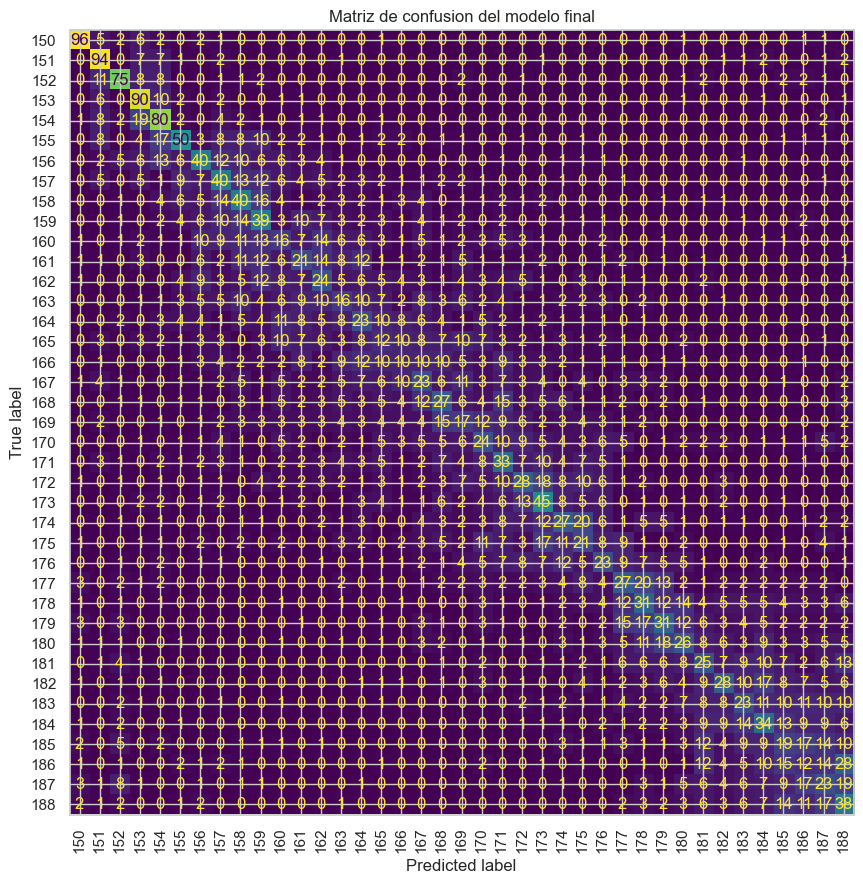

In [15]:
best_benchmark_name = str(benchmark_df.iloc[0]['model_name'])
best_model_name = best_benchmark_name
best_estimator = fitted_models[best_benchmark_name]
best_evaluation = fixed_evaluations[best_benchmark_name]
vectorizer = best_estimator.named_steps['vectorizer']
classifier = best_estimator.named_steps['model']
best_params = {
    'vectorizer__analyzer': vectorizer.analyzer,
    'vectorizer__ngram_range': vectorizer.ngram_range,
    'vectorizer__min_df': vectorizer.min_df,
    'vectorizer__max_features': vectorizer.max_features,
    'vectorizer__sublinear_tf': vectorizer.sublinear_tf,
    'vectorizer__lowercase': vectorizer.lowercase,
    'model__name': classifier.__class__.__name__,
    'model__C': classifier.C,
}
best_source = 'modelo_final_unico'
best_fit_seconds = float(benchmark_df.iloc[0]['fit_seconds'])

comparison_table = benchmark_df[['model_name', 'train_accuracy', 'valid_accuracy', 'fit_seconds']].copy()
comparison_table['stage'] = 'modelo_final'
comparison_table = comparison_table.sort_values(['valid_accuracy', 'train_accuracy'], ascending=False).reset_index(drop=True)
display(comparison_table)

print('Mejor modelo final:', best_model_name)
print('Fuente de seleccion:', best_source)
print('Configuracion final:')
display(pd.DataFrame([best_params]))

print(best_evaluation['classification_report'])

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(best_evaluation['confusion_matrix'], display_labels=sorted(y_valid.unique())).plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False,
)
ax.set_title('Matriz de confusion del modelo final')
plt.tight_layout()
plt.show()


## 9. Interpretacion del modelo lineal final

Como el clasificador final es un `LinearSVC` sobre `TF-IDF` por caracteres, podemos inspeccionar directamente los n-gramas con mayor peso por clase.
Esto mantiene la interpretacion alineada con las practicas del curso y evita agregar ensamblajes innecesarios.


In [16]:
interpretation_estimator = best_estimator
top_features = extract_top_features(interpretation_estimator, top_n=10)
display(top_features.head(50))


,decade,rank,feature,coefficient
0,150,1,Carta,1.258672
1,150,2,a,1.107581
2,150,3,Cart,1.087928
3,150,4,Car,1.080168
4,150,5,rta d,1.047267
5,150,6,arta,0.970103
6,150,7,rey,0.904810
7,150,8,rey,0.811795
8,150,9,Rela,0.807229
9,150,10,4tt,0.798604


## 10. Ultima submission del grupo

Como el grupo ya completo las cinco pruebas requeridas, este notebook se concentra solo en generar la ultima `submission` con el mejor modelo local encontrado.


In [17]:
kaggle_plan = pd.DataFrame([
    {'submission': 5, 'modelo': best_model_name, 'objetivo': 'ultima prueba con el mejor modelo lineal por caracteres'},
])
display(kaggle_plan)


,submission,modelo,objetivo
0,5,char_tfidf_svc_final,ultima prueba con el mejor modelo lineal por caracteres


## 11. Entrenamiento final sobre todo el train limpio y exportacion

Una vez seleccionado el mejor modelo, lo reentrenamos sobre todo el conjunto limpio y generamos los artefactos que exige la entrega:

- `submission.csv`
- `modelo_final.joblib`
- `metricas_resumen.json`

In [18]:
final_model = best_estimator
final_model.fit(clean_train_df['text'], clean_train_df['decade'])
final_predictions = final_model.predict(clean_eval_df['text'])
model_to_save = final_model

submission_df = create_submission(clean_eval_df, final_predictions)
submission_df.to_csv(SUBMISSION_PATH, index=False)
joblib.dump(model_to_save, MODEL_PATH)

metrics_payload = {
    'schema_report': schema_info,
    'cleaning_report': cleaning_report,
    'benchmark': benchmark_df,
    'search_summary': search_summary,
    'best_model_name': best_model_name,
    'best_source': best_source,
    'best_params': best_params,
    'best_valid_accuracy': best_evaluation['valid_accuracy'],
    'top_features_preview': top_features.head(40),
}
METRICS_PATH.write_text(json.dumps(make_json_safe(metrics_payload), indent=2, ensure_ascii=False), encoding='utf-8')

display(submission_df.head())
print(f'Submission guardado en: {SUBMISSION_PATH}')
print(f'Modelo guardado en: {MODEL_PATH}')
print(f'Metricas guardadas en: {METRICS_PATH}')
print(f'Filas del submission: {len(submission_df)}')
print(f"Rango de clases predichas: {int(submission_df['answer'].min())} - {int(submission_df['answer'].max())}")


,id,answer
0,0,173
1,1,185
2,2,150
3,3,169
4,4,153


Submission guardado en: c:\Users\yefra\Downloads\textClassificationSystemByDecadeProyectML\submission.csv
Modelo guardado en: c:\Users\yefra\Downloads\textClassificationSystemByDecadeProyectML\modelo_final.joblib
Metricas guardadas en: c:\Users\yefra\Downloads\textClassificationSystemByDecadeProyectML\metricas_resumen.json
Filas del submission: 3490
Rango de clases predichas: 150 - 188
